In [1]:
import torch

if torch.cuda.is_available():
    print("GPU is available!")
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available. Running on CPU.")

GPU is available!
GPU Name: NVIDIA A100-SXM4-40GB


In [2]:
# Clone repo and install
!git clone https://github.com/SlaviXG/thinking-inside-the-box.git
%cd thinking-inside-the-box
!pip install -e . -q

Cloning into 'thinking-inside-the-box'...
remote: Enumerating objects: 240, done.
remote: Counting objects: 100% (240/240), done.
remote: Compressing objects: 100% (167/167), done.
remote: Total 240 (delta 135), reused 175 (delta 70), pack-reused 0 (from 0)
Receiving objects: 100% (240/240), 532.28 KiB | 2.49 MiB/s, done.
Resolving deltas: 100% (135/135), done.
/content/thinking-inside-the-box
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 41.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 89.5 MB/s eta 0:00:00


In [3]:
# Upload your kaggle.json first (one-time), then:
from google.colab import files
files.upload()  # select kaggle.json

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!mkdir -p data
!kaggle datasets download -d ealtman2019/ibm-transactions-for-anti-money-laundering-aml \
    -f LI-Small_Trans.csv -p data/ --unzip
!ls -lh data/

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml
License(s): Community Data License Agreement - Sharing - Version 1.0
100% 620M/620M [00:51<00:00, 12.6MB/s]

total 621M
-rw-r--r-- 1 root root 621M Jul  8  2025 LI-Small_Trans.csv


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

DRIVE_DIR = '/content/drive/MyDrive/thinking-inside-the-box'
os.makedirs(DRIVE_DIR, exist_ok=True)
print(f'Drive mounted. Checkpoints will be saved to {DRIVE_DIR}')

In [ ]:
# Prevents Colab idle timeout during long runs.
# Run this before starting benchmarks, then leave the tab open.
from IPython.display import Javascript
display(Javascript("""function keepAlive() {
    document.querySelector("colab-toolbar-button#connect").click();
}
setInterval(keepAlive, 60000);
"""))

In [4]:
import pandas as pd
from src.config import Config
from src.graph.networkx_store import NetworkXGraphStore
from src.data.aml_ingestor import AMLIngestor

# Minimal synthetic transactions - mirrors IBM AML schema
mock_rows = [
    {"Timestamp": "2023-01-01", "From Bank": 1, "Account": "A1",
      "To Bank": 2, "Account.1": "A2", "Amount Received": 100.0,
      "Receiving Currency": "USD", "Amount Paid": 100.0,
      "Payment Currency": "USD", "Payment Format": "Wire", "Is Laundering": 0},
    {"Timestamp": "2023-01-02", "From Bank": 1, "Account": "A1",
      "To Bank": 3, "Account.1": "A3", "Amount Received": 5000.0,
      "Receiving Currency": "USD", "Amount Paid": 5000.0,
      "Payment Currency": "BTC", "Payment Format": "Crypto", "Is Laundering": 1},
    {"Timestamp": "2023-01-03", "From Bank": 2, "Account": "A2",
      "To Bank": 3, "Account.1": "A3", "Amount Received": 200.0,
      "Receiving Currency": "EUR", "Amount Paid": 200.0,
      "Payment Currency": "EUR", "Payment Format": "ACH", "Is Laundering": 0},
]
df = pd.DataFrame(mock_rows)

config = Config(graph_backend="networkx", bank_id=0)
store = NetworkXGraphStore(config)
store.connect()  # initialises the graph

ingestor = AMLIngestor(config)
nodes = ingestor.prepare_nodes(df)
edges = ingestor.prepare_edges(df)

store.create_schema()
store.ingest(nodes, edges)

context = store.retrieve_context("A1", limit=10)
print("=== RAG context for A1 ===")
print(context)

store.close()
print("\nSmoke test passed.")

=== RAG context for A1 ===
Transaction History for Account A1:
- A1 sent 100.0 USD (Wire) to A2 at 2023-01-01
- A1 sent 5000.0 BTC (Crypto) to A3 at 2023-01-02
- A2 sent 200.0 EUR (ACH) to A3 at 2023-01-03


Smoke test passed.


In [5]:
from src.config import Config
from src.graph.factory import GraphStoreFactory
from src.model.model_loader import load_model, load_tokenizer, attach_lora
from src.data.aml_ingestor import AMLIngestor
from src.pipeline.investigation import InvestigationPipeline

config = Config(
    csv_path="data/LI-Small_Trans.csv",
    graph_backend="kuzu",
    bank_id=0,              # all banks
    retrieval_limit=20,
    max_new_tokens=1024,
)

# Load model (downloads ~5GB on first run)
# Skip if already loaded in this session
if "model" not in dir() or model is None:
    print("Loading model...")
    model = load_model(config)
    tokenizer = load_tokenizer(config)
    model = attach_lora(model, config)
    print("Model ready.")
else:
    print("Model already loaded, skipping.")

# Build graph
print("\nBuilding graph...")
ingestor = AMLIngestor(config)
df = ingestor.load_partition()
graph_store = GraphStoreFactory.create(config)
ingestor.run_from_df(graph_store, df)

# Pick one account from each class to investigate
train_df, _, test_df = ingestor.split(df)
clean_account = test_df[test_df["label"] == 0]["account_id"].iloc[0]
suspicious_account = test_df[test_df["label"] == 1]["account_id"].iloc[0]

pipeline = InvestigationPipeline(graph_store, model, tokenizer, config)

print(f"\n--- Investigating CLEAN account: {clean_account} ---")
print(pipeline.investigate(clean_account))

print(f"\n--- Investigating SUSPICIOUS account: {suspicious_account} ---")
print(pipeline.investigate(suspicious_account))

graph_store.close()

Loading model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/826 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/181 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

trainable params: 3,407,872 || all params: 8,033,669,120 || trainable%: 0.0424
Model ready.

Building graph...
Ingesting 6924049 transactions...
  705903 unique accounts, 6924049 transactions.
Ingest complete.

--- Investigating CLEAN account: 80E121970 ---
--- Investigating account 80E121970 ---
Alright, I'm looking at these transaction logs to see if there's any suspicious activity. The account in question is 80E121970, and there are a bunch of transactions from 80A4E09B0 and 8008C9360 to it. 

First, I notice that 80A4E09B0 is sending both credit card and cheque payments to 80E121970. The amounts are around $3,320.90 and $12,062.05. These seem like they could be regular payments, but I'm not sure yet.

Looking at the dates, there are multiple transactions on the same day, like on 2022/09/01, where both credit card and cheque payments were made. That's a bit unusual because usually, transactions from the same account might not have multiple types on the same day. Maybe it's a sign of

In [ ]:
# # The log shows samples=20 training and only 10 accounts evaluated per bank. With ~1-2% laundering rate in IBM AML, 10 eval
# #  samples gives an expected 0.1-0.2 positive examples - statistically we'll almost always see zero positives in ground truth,
# #  making F1=0 mathematically guaranteed regardless of model quality.

# # Now, serious training
# config = Config(
#     csv_path="data/LI-Small_Trans.csv",
#     graph_backend="kuzu",
#     num_clients=3,
#     num_rounds=5,
#     local_epochs=2,
#     max_train_samples=200,
#     max_eval_samples=100,
# )

# # Pass model/tokenizer from the prev. cells to avoid reloading into VRAM
# start_server(config, model=model, tokenizer=tokenizer)

Reusing provided model and tokenizer.

Ingesting 33245 transactions...
  4245 unique accounts, 33245 transactions.
Ingest complete.
[Client bank_id=1] train=806 (13 pos / 793 neg)  val=172  test=174 (3 pos)


KeyboardInterrupt: 

## Trilemma Benchmark

Full evaluation run measuring all three axes:
- **Utility** - macro F1 on the full test split per round per client
- **Efficiency** - adapter delta bytes (FLoRA) vs theoretical full-model bytes (FedAvg) per round
- **Privacy** - MIA AUC per round per client (target: near 0.5)

In [ ]:
# from src.config import Config
# from src.federation.server import start_server

# # Full benchmark config.
# # bank_ids selects the three most class-balanced partitions in the IBM AML dataset
# # (banks 20, 11, 12 - highest positive account counts at 1.4-1.9% laundering rate).
# # max_eval_samples=0 uses the full test split per client (~520/470/380 accounts each).
# # max_eval_tokens=512: enough for brief chain-of-thought + VERDICT line.
# #   - 256 is too short (reasoning gets cut off before the verdict on a fresh model)
# #   - 1024 makes eval ~2x slower with no quality benefit after fine-tuning
# # Estimated runtime on A100: ~60 min (FLoRA) + ~60 min (FedAvg) + ~50 min (centralised) = ~3 h total
# benchmark_config = Config(
#     csv_path="data/LI-Small_Trans.csv",
#     graph_backend="kuzu",
#     num_clients=3,
#     bank_ids=(20, 11, 12),  # banks with highest positive account counts
#     num_rounds=3,
#     local_epochs=1,
#     max_train_samples=100,
#     max_eval_samples=0,     # full test split - needed to capture all ~10/8/5 positives per bank
#     max_eval_tokens=1024,
#     mia_n_members=50,
#     mia_n_nonmembers=50,
# )

# history = start_server(benchmark_config, model=model, tokenizer=tokenizer)

Reusing provided model and tokenizer.

Ingesting 120114 transactions...
  14566 unique accounts, 120114 transactions.
Ingest complete.
[Client bank_id=20] train=2933 (46 pos / 2887 neg)  val=628  test=629 (10 pos)
Ingesting 123456 transactions...
  15980 unique accounts, 123456 transactions.
Ingest complete.
[Client bank_id=11] train=3387 (45 pos / 3342 neg)  val=725  test=727 (10 pos)
Ingesting 64465 transactions...
  8449 unique accounts, 64465 transactions.
Ingest complete.
[Client bank_id=12] train=1773 (25 pos / 1748 neg)  val=379  test=381 (6 pos)

Round 1/3
  [fit] bank_id=20 loss=0.1299 samples=100
  [fit] bank_id=11 loss=0.1194 samples=100
  [fit] bank_id=12 loss=0.1167 samples=100

[FLoRA] Round 1 - aggregating 3 clients
[FLoRA] Round 1 - aggregation complete

[MIA] Round 1
  [mia] bank_id=20 AUC=0.386
  [mia] bank_id=11 AUC=0.458
  [mia] bank_id=12 AUC=0.518
--- Investigating account 8014DDA20 ---
--- Investigating account 80263D820 ---
--- Investigating account 81959AB91 --

In [ ]:
from src.config import Config
from src.federation.server import start_server

# Benchmark config.
# bank_ids=(20,11,12): highest positive account counts in IBM AML (65/56/36 pos accounts).
#
# max_eval_samples=60: stratified eval - ALL positives (~6-10 per bank) + negatives to fill
#   the budget. Random sampling risks zero positives in eval; this guarantees coverage.
#   Full test split (max_eval_samples=0) has ~500 accounts/bank = 23x slower, use only
#   for final publication runs with unlimited compute.
#
# max_eval_tokens=1024
#
# Estimated runtime on A100 with these settings:
#   FLoRA (cell 8):        ~130 min (10 rounds x ~13 min)
#   FedAvg (cell 9):       ~27 min  (10 rounds x ~2.7 min)
#   Centralised (cell 10): ~16 min  (10 rounds x ~1.6 min)
#   Total:                 ~3 h
benchmark_config = Config(
    csv_path="data/LI-Small_Trans.csv",
    graph_backend="kuzu",
    num_clients=3,
    bank_ids=(20, 11, 12),
    num_rounds=10,
    local_epochs=1,
    max_train_samples=100,
    max_eval_samples=1,     # any non-zero: all positives + equal negatives (1:1 balanced)
    max_eval_tokens=1024,    # brief reasoning + verdict; 1024 = 2.5x slower
    mia_n_members=50,
    mia_n_nonmembers=50,
    checkpoint_path=f"{DRIVE_DIR}/history_flora_rag.json",
)

history = start_server(benchmark_config, model=model, tokenizer=tokenizer)

In [7]:
from src.federation.baselines import run_centralised

# Centralised baseline: all benchmark bank data merged, single model, no federation.
# Utility upper bound - best possible F1 when privacy is not a concern.
history_centralised = run_centralised(benchmark_config, model=model, tokenizer=tokenizer)

Reusing provided model and tokenizer.

[Centralised] Loading merged partition...
Ingesting 308035 transactions...
  37232 unique accounts, 308035 transactions.
Ingest complete.
[Client bank_id=0] train=8093 (116 pos / 7977 neg)  val=1734  test=1735 (25 pos)

[Centralised] Round 1/3
  [fit] bank_id=0 loss=0.1149 samples=100
--- Investigating account 801752F10 ---
--- Investigating account 80298E290 ---
--- Investigating account 801FE35F0 ---
--- Investigating account 800F136C0 ---
--- Investigating account 800211630 ---
--- Investigating account 81AF83E81 ---
--- Investigating account 81972D470 ---
--- Investigating account 802C216E0 ---
--- Investigating account 80024CCB0 ---
--- Investigating account 8001696B0 ---
--- Investigating account 8001DC570 ---
--- Investigating account 800B40290 ---
--- Investigating account 800B29F20 ---
--- Investigating account 8000FA930 ---
--- Investigating account 8000FB7D0 ---
--- Investigating account 800443CB0 ---
--- Investigating account 801524F90

In [ ]:
import dataclasses
from src.federation.server import start_server

fedavg_config = dataclasses.replace(
    benchmark_config,
    checkpoint_path=f"{DRIVE_DIR}/history_fedavg_rag.json",
)
history_fedavg = start_server(fedavg_config, model=model, tokenizer=tokenizer,
    aggregation="fedavg")

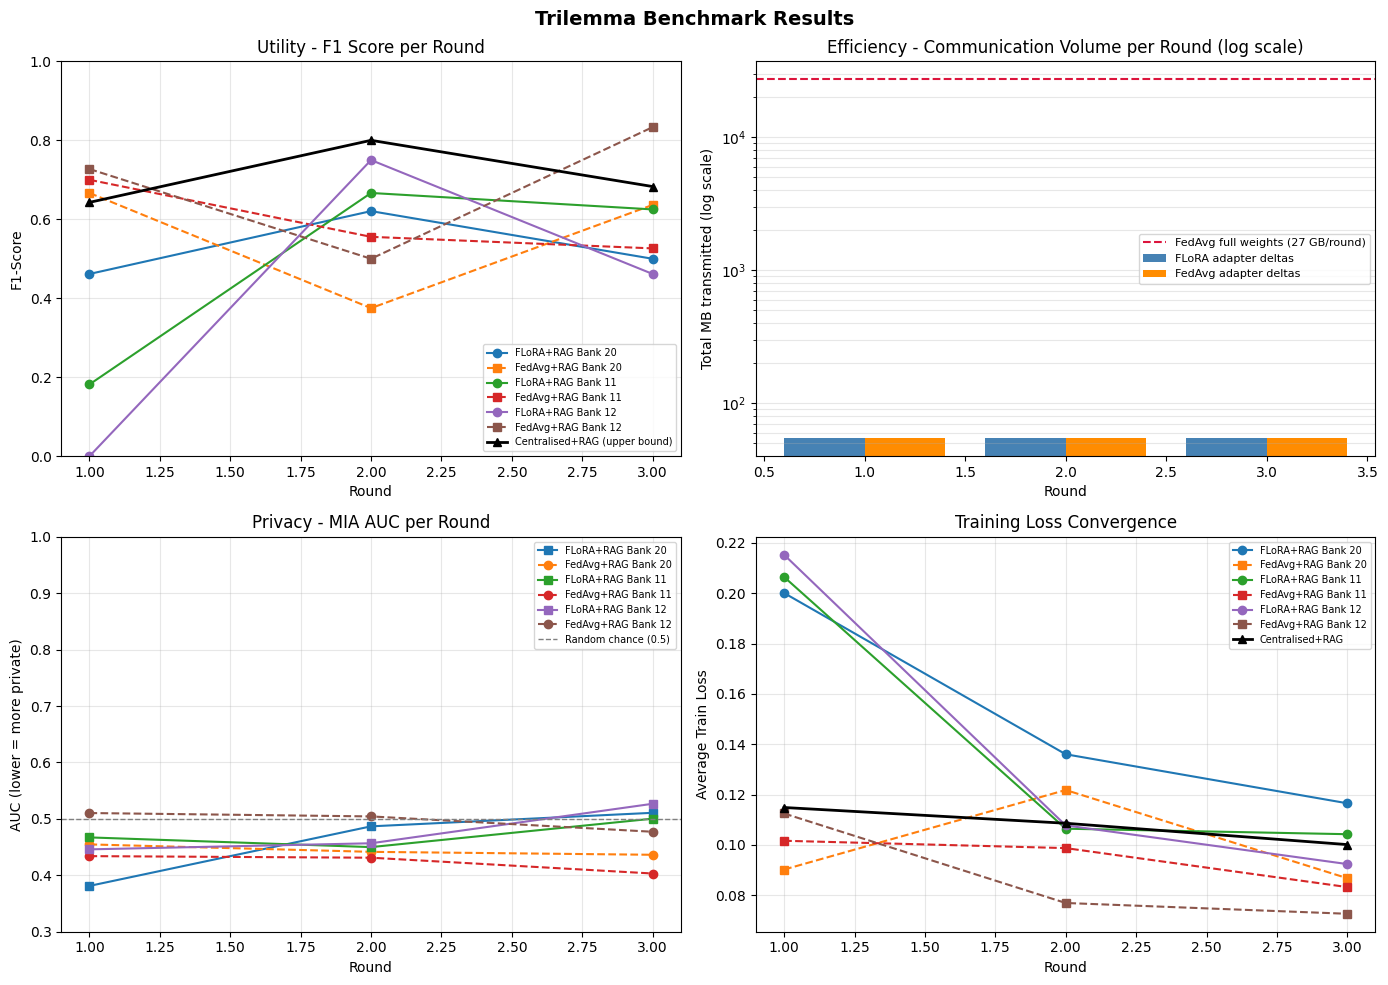

=== Trilemma Summary (final round) ===
Metric                                      FLoRA+RAG     FedAvg+RAG Centralised+RAG
----------------------------------------------------------------------------------
Utility (F1)                                    0.529          0.665          0.683
Efficiency (adapter delta MB, total)           163.8M         163.8M            N/A
Theoretical full-weight FedAvg (MB)            81792M         81792M            N/A
Privacy (MIA AUC)                               0.513          0.439    N/A (no FL)
Compression vs full-weight FedAvg                499x             1x            N/A


In [13]:
import matplotlib.pyplot as plt
import numpy as np

rounds = list(range(1, len(history["f1"]) + 1))
bank_ids = benchmark_config.bank_ids
client_labels = [f"Bank {bid}" for bid in bank_ids]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Trilemma Benchmark Results", fontsize=14, fontweight="bold")

# --- Utility: F1 per round - FLoRA+RAG vs FedAvg vs Centralised ---
ax = axes[0, 0]
for i, label in enumerate(client_labels):
    ax.plot(rounds, [history["f1"][r][i] for r in range(len(rounds))],
            marker="o", label=f"FLoRA+RAG {label}")
    ax.plot(rounds, [history_fedavg["f1"][r][i] for r in range(len(rounds))],
            marker="s", linestyle="--", label=f"FedAvg+RAG {label}")
centralised_f1 = [history_centralised["f1"][r][0] for r in range(len(rounds))]
ax.plot(rounds, centralised_f1, marker="^", linewidth=2, color="black", label="Centralised+RAG (upper bound)")
ax.set_title("Utility - F1 Score per Round")
ax.set_xlabel("Round")
ax.set_ylabel("F1-Score")
ax.set_ylim(0, 1)
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# --- Efficiency: comm volume FLoRA vs FedAvg (log scale) ---
ax = axes[0, 1]
flora_mb_per_round = [sum(history["comm_bytes_flora"][r]) / 1e6 for r in range(len(rounds))]
fedavg_mb_per_round = [sum(history_fedavg["comm_bytes_flora"][r]) / 1e6 for r in range(len(rounds))]
fedavg_full_mb = history["comm_bytes_fedavg_per_round"] / 1e6
fedavg_full_gb = fedavg_full_mb / 1000
ax.bar([r - 0.2 for r in rounds], flora_mb_per_round, width=0.4, label="FLoRA adapter deltas", color="steelblue")
ax.bar([r + 0.2 for r in rounds], fedavg_mb_per_round, width=0.4, label="FedAvg adapter deltas", color="darkorange")
ax.axhline(fedavg_full_mb, color="crimson", linestyle="--", linewidth=1.5,
           label=f"FedAvg full weights ({fedavg_full_gb:.0f} GB/round)")
ax.set_yscale("log")
ax.set_title("Efficiency - Communication Volume per Round (log scale)")
ax.set_xlabel("Round")
ax.set_ylabel("Total MB transmitted (log scale)")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3, which="both", axis="y")

# --- Privacy: MIA AUC per round per client (FLoRA only - centralised has no MIA) ---
ax = axes[1, 0]
for i, label in enumerate(client_labels):
    ax.plot(rounds, [history["mia_auc"][r][i] for r in range(len(rounds))],
            marker="s", label=f"FLoRA+RAG {label}")
    ax.plot(rounds, [history_fedavg["mia_auc"][r][i] for r in range(len(rounds))],
            marker="o", linestyle="--", label=f"FedAvg+RAG {label}")
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="Random chance (0.5)")
ax.set_title("Privacy - MIA AUC per Round")
ax.set_xlabel("Round")
ax.set_ylabel("AUC (lower = more private)")
ax.set_ylim(0.3, 1.0)
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

# --- Training loss convergence ---
ax = axes[1, 1]
for i, label in enumerate(client_labels):
    ax.plot(rounds, [history["train_loss"][r][i] for r in range(len(rounds))],
            marker="o", label=f"FLoRA+RAG {label}")
    ax.plot(rounds, [history_fedavg["train_loss"][r][i] for r in range(len(rounds))],
            marker="s", linestyle="--", label=f"FedAvg+RAG {label}")
ax.plot(rounds, [history_centralised["train_loss"][r][0] for r in range(len(rounds))],
        marker="^", linewidth=2, color="black", label="Centralised+RAG")
ax.set_title("Training Loss Convergence")
ax.set_xlabel("Round")
ax.set_ylabel("Average Train Loss")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("assets/benchmark_results.pdf", dpi=150, bbox_inches="tight")
plt.show()

# --- Summary table ---
print("=== Trilemma Summary (final round) ===")
print(f"{'Metric':<38} {'FLoRA+RAG':>14} {'FedAvg+RAG':>14} {'Centralised+RAG':>14}")
print("-" * 82)

avg_f1_flora  = np.mean([history["f1"][-1][i] for i in range(len(bank_ids))])
avg_f1_fedavg = np.mean([history_fedavg["f1"][-1][i] for i in range(len(bank_ids))])
avg_f1_central = history_centralised["f1"][-1][0]

avg_mia_flora  = np.mean([history["mia_auc"][-1][i] for i in range(len(bank_ids))])
avg_mia_fedavg = np.mean([history_fedavg["mia_auc"][-1][i] for i in range(len(bank_ids))])

flora_total_mb  = sum(sum(history["comm_bytes_flora"][r]) for r in range(len(rounds))) / 1e6
fedavg_total_mb = sum(sum(history_fedavg["comm_bytes_flora"][r]) for r in range(len(rounds))) / 1e6
fedavg_full_total_mb = history["comm_bytes_fedavg_per_round"] * len(rounds) / 1e6

print(f"{'Utility (F1)':<38} {avg_f1_flora:>14.3f} {avg_f1_fedavg:>14.3f} {avg_f1_central:>14.3f}")
print(f"{'Efficiency (adapter delta MB, total)':<38} {flora_total_mb:>13.1f}M {fedavg_total_mb:>13.1f}M {'N/A':>14}")
print(f"{'Theoretical full-weight FedAvg (MB)':<38} {fedavg_full_total_mb:>13.0f}M {fedavg_full_total_mb:>13.0f}M {'N/A':>14}")
print(f"{'Privacy (MIA AUC)':<38} {avg_mia_flora:>14.3f} {avg_mia_fedavg:>14.3f} {'N/A (no FL)':>14}")
print(f"{'Compression vs full-weight FedAvg':<38} {fedavg_full_total_mb/flora_total_mb:>13.0f}x {'1x':>14} {'N/A':>14}")


In [ ]:
import json, os

os.makedirs("results", exist_ok=True)

results = {
    "history_flora_rag.json":        globals().get("history"),
    "history_fedavg_rag.json":       globals().get("history_fedavg"),
    "history_centralised_rag.json":  globals().get("history_centralised"),
}

for filename, data in results.items():
    if data is None:
        print(f"[SKIP] {filename} - variable not found (run may not have completed)")
        continue
    local_path = f"results/{filename}"
    drive_path = f"{DRIVE_DIR}/{filename}"
    with open(local_path, "w") as f:
        json.dump(data, f)
    with open(drive_path, "w") as f:
        json.dump(data, f)
    n_rounds = len(data.get("f1", data.get("train_loss", [])))
    print(f"[SAVED] {filename} ({n_rounds} rounds) -> Drive + local")

In [ ]:
import json, os

print(f"Verifying results on Drive at {DRIVE_DIR}...")
print()

checks = [
    ("history_flora_rag.json",       "FLoRA+RAG"),
    ("history_fedavg_rag.json",      "FedAvg+RAG"),
    ("history_centralised_rag.json", "Centralised+RAG"),
]

all_ok = True
for filename, label in checks:
    fpath = f"{DRIVE_DIR}/{filename}"
    if os.path.exists(fpath):
        with open(fpath) as f:
            data = json.load(f)
        n_rounds = len(data.get("f1", data.get("train_loss", [])))
        print(f"  [OK] {label}: {n_rounds} rounds on Drive")
    else:
        print(f"  [MISSING] {label}: not found - run cell above first")
        all_ok = False

print()
if all_ok:
    print("All results verified. Disconnecting runtime...")
    from google.colab import runtime
    runtime.unassign()
else:
    print("Some results missing - check above before disconnecting.")